In [1]:
# Government Fund Utilization Capstone Analysis
# Week 4 - Day 5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("govt_fund_utilization.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 1000
Columns: 21


In [2]:
# Display dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Record_ID                   1000 non-null   str    
 1   Financial_Year              1000 non-null   str    
 2   Date_of_Fund_Release        1000 non-null   str    
 3   State                       1000 non-null   str    
 4   District                    1000 non-null   str    
 5   Department                  1000 non-null   str    
 6   Scheme_Name                 1000 non-null   str    
 7   Scheme_Code                 1000 non-null   str    
 8   Fund_Source                 1000 non-null   str    
 9   Implementing_Agency         1000 non-null   str    
 10  Sanctioned_Amount_Lakhs     1000 non-null   float64
 11  Fund_Released_Lakhs         1000 non-null   float64
 12  Fund_Utilized_Lakhs         940 non-null    float64
 13  Utilization_Percent         940 non-null    f

In [3]:
# Display first 5 records
df.head()

,Record_ID,Financial_Year,Date_of_Fund_Release,State,District,Department,Scheme_Name,Scheme_Code,Fund_Source,Implementing_Agency,...,Fund_Released_Lakhs,Fund_Utilized_Lakhs,Utilization_Percent,Physical_Target_Units,Physical_Achievement_Units,Beneficiaries_Target,Beneficiaries_Covered,Status,Audit_Remarks,Nodal_Officer_Contact
0,GFU00643,2022-23,2021-08-25,West Bengal,Siliguri,Ministry of Agriculture & Farmers Welfare,PM Kisan Samman Nidhi,PMKISAN,Central Sector,Gram Panchayat,...,517.65,212.25,41.00,427,38.0,4138,344.0,Delayed,Awaiting third-party audit clearance,Sunita Yadav - District Collector Office - sun...
1,GFU00763,2021-22,2023-04-16,Tamil Nadu,Salem,Ministry of Agriculture & Farmers Welfare,Pradhan Mantri Fasal Bima Yojana,PMFBY,Central Sector,State Nodal Agency,...,44.61,27.25,61.08,367,104.0,4988,1373.0,Delayed,Material procurement in progress,Rakesh Yadav - Block Development Officer - rak...
2,GFU00910,2023-24,2023-01-31,Kerala,Thiruvananthapuram,Ministry of Health & Family Welfare,National Health Mission,NHM,Centrally Sponsored (60:40),District Panchayat / Zilla Parishad,...,634.28,NaN,NaN,6,5.0,2151,1621.0,Delayed,Utilization certificate submitted and verified,Rakesh Reddy - District Collector Office - rak...
3,GFU00200,2023-24,2024-08-29,West Bengal,Asansol,Ministry of Education,PM Poshan (Mid-Day Meal Scheme),PMPOSHAN,Centrally Sponsored (60:40),NGO / Partner Organisation,...,247.44,147.35,59.55,55,3.0,4122,213.0,Ongoing,Fund utilization certificate pending,Anjali Sharma - Assistant Engineer - anjali.sh...
4,GFU00587,2021-22,2021-06-21,Karnataka,Belagavi,Ministry of Rural Development,Pradhan Mantri Awas Yojana - Gramin,PMAY-G,Centrally Sponsored (60:40),District Panchayat / Zilla Parishad,...,593.82,451.45,76.02,406,337.0,2984,2565.0,Delayed,Fund utilization certificate pending,Kavita Das - Scheme Nodal Officer - kavita.das...


In [4]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
Record_ID                      0
Financial_Year                 0
Date_of_Fund_Release           0
State                          0
District                       0
Department                     0
Scheme_Name                    0
Scheme_Code                    0
Fund_Source                    0
Implementing_Agency            0
Sanctioned_Amount_Lakhs        0
Fund_Released_Lakhs            0
Fund_Utilized_Lakhs           60
Utilization_Percent           60
Physical_Target_Units          0
Physical_Achievement_Units    25
Beneficiaries_Target           0
Beneficiaries_Covered         45
Status                         0
Audit_Remarks                 70
Nodal_Officer_Contact          0
dtype: int64


In [5]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
# Data Cleaning

# Create a copy of the original dataset
clean_df = df.copy()

# Remove contact information from the analysis
clean_df = clean_df.drop(columns=["Nodal_Officer_Contact"])

# Convert date column to datetime
clean_df["Date_of_Fund_Release"] = pd.to_datetime(
    clean_df["Date_of_Fund_Release"],
    errors="coerce"
)

# Handle missing numeric values using median
numeric_columns = [
    "Fund_Utilized_Lakhs",
    "Utilization_Percent",
    "Physical_Achievement_Units",
    "Beneficiaries_Covered"
]

for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

# Handle missing audit remarks
clean_df["Audit_Remarks"] = clean_df["Audit_Remarks"].fillna(
    "No audit remark provided"
)

# Check remaining missing values
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

print("\nCleaned dataset shape:")
print(clean_df.shape)

Missing values after cleaning:
Record_ID                     0
Financial_Year                0
Date_of_Fund_Release          0
State                         0
District                      0
Department                    0
Scheme_Name                   0
Scheme_Code                   0
Fund_Source                   0
Implementing_Agency           0
Sanctioned_Amount_Lakhs       0
Fund_Released_Lakhs           0
Fund_Utilized_Lakhs           0
Utilization_Percent           0
Physical_Target_Units         0
Physical_Achievement_Units    0
Beneficiaries_Target          0
Beneficiaries_Covered         0
Status                        0
Audit_Remarks                 0
dtype: int64

Cleaned dataset shape:
(1000, 20)


In [7]:
# Verify cleaned dataset

print("Duplicate rows:", clean_df.duplicated().sum())
print("Date column type:", clean_df["Date_of_Fund_Release"].dtype)
print("Total rows:", len(clean_df))
print("Total columns:", len(clean_df.columns))

Duplicate rows: 0
Date column type: datetime64[us]
Total rows: 1000
Total columns: 20


# Business Question

## Main Business Question

How effectively are government funds being utilized across different states, departments, schemes, and implementing agencies, and what factors are associated with differences in fund utilization and beneficiary coverage?

## Analysis Objectives

1. Measure overall fund utilization and compare sanctioned, released, and utilized funds.
2. Identify differences in fund utilization across states, departments, schemes, and implementing agencies.
3. Examine the relationship between fund utilization, physical achievement, and beneficiary coverage.
4. Analyze whether fund utilization differs significantly between government project statuses.
5. Identify areas where fund utilization or beneficiary coverage is relatively low and may require management attention.

## Key Business Metrics

- Total Sanctioned Amount
- Total Fund Released
- Total Fund Utilized
- Overall Utilization Percentage
- Physical Target Achievement Rate
- Beneficiary Coverage Rate
- Number of Schemes
- Number of States

In [8]:
# Calculate key business metrics

total_sanctioned = clean_df["Sanctioned_Amount_Lakhs"].sum()
total_released = clean_df["Fund_Released_Lakhs"].sum()
total_utilized = clean_df["Fund_Utilized_Lakhs"].sum()

overall_utilization = (total_utilized / total_released) * 100

physical_achievement_rate = (
    clean_df["Physical_Achievement_Units"].sum()
    / clean_df["Physical_Target_Units"].sum()
) * 100

beneficiary_coverage_rate = (
    clean_df["Beneficiaries_Covered"].sum()
    / clean_df["Beneficiaries_Target"].sum()
) * 100

number_of_schemes = clean_df["Scheme_Name"].nunique()
number_of_states = clean_df["State"].nunique()

print("KEY BUSINESS METRICS")
print("-" * 40)
print(f"Total Sanctioned Amount: {total_sanctioned:.2f} Lakhs")
print(f"Total Fund Released: {total_released:.2f} Lakhs")
print(f"Total Fund Utilized: {total_utilized:.2f} Lakhs")
print(f"Overall Fund Utilization: {overall_utilization:.2f}%")
print(f"Physical Achievement Rate: {physical_achievement_rate:.2f}%")
print(f"Beneficiary Coverage Rate: {beneficiary_coverage_rate:.2f}%")
print(f"Number of Schemes: {number_of_schemes}")
print(f"Number of States: {number_of_states}")

KEY BUSINESS METRICS
----------------------------------------
Total Sanctioned Amount: 400073.92 Lakhs
Total Fund Released: 297951.32 Lakhs
Total Fund Utilized: 201934.77 Lakhs
Overall Fund Utilization: 67.77%
Physical Achievement Rate: 64.18%
Beneficiary Coverage Rate: 61.41%
Number of Schemes: 11
Number of States: 10


In [9]:
# Statistical summary of numerical variables

clean_df.describe()

,Date_of_Fund_Release,Sanctioned_Amount_Lakhs,Fund_Released_Lakhs,Fund_Utilized_Lakhs,Utilization_Percent,Physical_Target_Units,Physical_Achievement_Units,Beneficiaries_Target,Beneficiaries_Covered
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2023-03-29 15:02:52.800000,400.073920,297.951320,201.934770,69.141600,258.332000,165.796000,2522.802000,1549.129000
min,2021-04-01 00:00:00,20.720000,10.970000,0.000000,0.000000,5.000000,0.000000,50.000000,0.000000
25%,2022-03-23 00:00:00,191.462500,142.775000,67.677500,51.255000,137.000000,32.000000,1245.500000,357.750000
50%,2023-03-27 00:00:00,391.225000,285.745000,174.440000,81.965000,263.000000,129.000000,2505.000000,1202.000000
75%,2024-04-03 06:00:00,615.342500,437.795000,307.487500,91.195000,382.000000,279.000000,3802.000000,2501.250000
max,2025-03-27 00:00:00,799.870000,781.380000,732.580000,99.970000,499.000000,497.000000,4997.000000,4914.000000
std,NaN,232.578848,184.016642,159.447671,29.655303,142.702192,144.272863,1435.877992,1356.574038


In [10]:
# Count unique values in important categorical columns

categorical_columns = [
    "Financial_Year",
    "State",
    "Department",
    "Scheme_Name",
    "Fund_Source",
    "Implementing_Agency",
    "Status"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    print("Unique values:", clean_df[column].nunique())
    print(clean_df[column].value_counts().head(10))


Financial_Year
----------------------------------------
Unique values: 4
Financial_Year
2023-24    307
2024-25    274
2022-23    263
2021-22    156
Name: count, dtype: int64

State
----------------------------------------
Unique values: 10
State
Gujarat           114
West Bengal       111
Tamil Nadu        106
Kerala            105
Maharashtra       101
Bihar              97
Madhya Pradesh     96
Uttar Pradesh      95
Rajasthan          89
Karnataka          86
Name: count, dtype: int64

Department
----------------------------------------
Unique values: 5
Department
Ministry of Rural Development                257
Ministry of Jal Shakti                       210
Ministry of Health & Family Welfare          186
Ministry of Education                        178
Ministry of Agriculture & Farmers Welfare    169
Name: count, dtype: int64

Scheme_Name
----------------------------------------
Unique values: 11
Scheme_Name
Swachh Bharat Mission - Gramin                               107
Jal Je

In [11]:
# Fund utilization by state

state_analysis = clean_df.groupby("State").agg(
    Total_Released=("Fund_Released_Lakhs", "sum"),
    Total_Utilized=("Fund_Utilized_Lakhs", "sum"),
    Average_Utilization=("Utilization_Percent", "mean")
).reset_index()

state_analysis["Calculated_Utilization_Percent"] = (
    state_analysis["Total_Utilized"]
    / state_analysis["Total_Released"]
) * 100

state_analysis = state_analysis.sort_values(
    "Calculated_Utilization_Percent",
    ascending=False
)

state_analysis

,State,Total_Released,Total_Utilized,Average_Utilization,Calculated_Utilization_Percent
6,Rajasthan,30416.81,22302.37,73.901404,73.322515
9,West Bengal,35791.06,25747.63,72.493694,71.938719
3,Kerala,31837.56,22544.29,71.165333,70.810357
4,Madhya Pradesh,27061.35,18868.57,70.087865,69.725162
0,Bihar,30653.86,21008.71,72.838454,68.535284
2,Karnataka,26081.72,17811.00,71.418547,68.289208
7,Tamil Nadu,34074.19,22727.17,64.461509,66.699076
5,Maharashtra,29314.65,19187.13,69.348465,65.452359
1,Gujarat,27875.91,16946.79,63.161447,60.793675
8,Uttar Pradesh,24844.21,14791.11,63.915105,59.535441


In [12]:
# Fund utilization by department

department_analysis = clean_df.groupby("Department").agg(
    Total_Released=("Fund_Released_Lakhs", "sum"),
    Total_Utilized=("Fund_Utilized_Lakhs", "sum"),
    Average_Utilization=("Utilization_Percent", "mean")
).reset_index()

department_analysis["Calculated_Utilization_Percent"] = (
    department_analysis["Total_Utilized"]
    / department_analysis["Total_Released"]
) * 100

department_analysis = department_analysis.sort_values(
    "Calculated_Utilization_Percent",
    ascending=False
)

department_analysis

,Department,Total_Released,Total_Utilized,Average_Utilization,Calculated_Utilization_Percent
3,Ministry of Jal Shakti,65478.75,46246.68,69.410810,70.628532
2,Ministry of Health & Family Welfare,54678.03,37574.22,71.430833,68.719045
1,Ministry of Education,51505.00,34559.00,68.111376,67.098340
4,Ministry of Rural Development,77160.21,51338.00,69.074027,66.534293
0,Ministry of Agriculture & Farmers Welfare,49129.33,32216.87,67.475414,65.575635


In [13]:
# Fund utilization by scheme

scheme_analysis = clean_df.groupby("Scheme_Name").agg(
    Total_Released=("Fund_Released_Lakhs", "sum"),
    Total_Utilized=("Fund_Utilized_Lakhs", "sum"),
    Average_Utilization=("Utilization_Percent", "mean"),
    Total_Beneficiaries_Target=("Beneficiaries_Target", "sum"),
    Total_Beneficiaries_Covered=("Beneficiaries_Covered", "sum")
).reset_index()

scheme_analysis["Calculated_Utilization_Percent"] = (
    scheme_analysis["Total_Utilized"]
    / scheme_analysis["Total_Released"]
) * 100

scheme_analysis["Beneficiary_Coverage_Percent"] = (
    scheme_analysis["Total_Beneficiaries_Covered"]
    / scheme_analysis["Total_Beneficiaries_Target"]
) * 100

scheme_analysis = scheme_analysis.sort_values(
    "Calculated_Utilization_Percent",
    ascending=False
)

scheme_analysis

,Scheme_Name,Total_Released,Total_Utilized,Average_Utilization,Total_Beneficiaries_Target,Total_Beneficiaries_Covered,Calculated_Utilization_Percent,Beneficiary_Coverage_Percent
5,PM Poshan (Mid-Day Meal Scheme),27101.95,19567.85,71.257704,286361,158911.0,72.200893,55.493241
0,Ayushman Bharat - Pradhan Mantri Jan Arogya Yo...,25658.05,18339.04,72.596954,212612,143161.0,71.474800,67.334393
1,Jal Jeevan Mission,33750.64,23983.00,71.072524,261057,157307.0,71.059393,60.257721
10,Swachh Bharat Mission - Gramin,31728.11,22263.68,67.811215,269024,171017.0,70.170206,63.569421
2,Mahatma Gandhi National Rural Employment Guara...,25172.86,17215.53,68.666034,189702,127468.0,68.389249,67.193809
6,Pradhan Mantri Awas Yojana - Gramin,27847.33,18897.59,69.750393,235357,134193.0,67.861407,57.016787
7,Pradhan Mantri Fasal Bima Yojana,20307.81,13600.75,66.637055,181298,105395.0,66.973002,58.133570
3,National Health Mission,29019.98,19235.18,70.406061,247390,170480.0,66.282541,68.911435
4,PM Kisan Samman Nidhi,28821.52,18616.12,68.112917,243570,141564.0,64.591042,58.120458
8,Pradhan Mantri Gram Sadak Yojana,24140.02,15224.88,68.769074,219782,127990.0,63.069045,58.234978


In [14]:
# Fund utilization by project status

status_analysis = clean_df.groupby("Status").agg(
    Total_Released=("Fund_Released_Lakhs", "sum"),
    Total_Utilized=("Fund_Utilized_Lakhs", "sum"),
    Average_Utilization=("Utilization_Percent", "mean"),
    Records=("Record_ID", "count")
).reset_index()

status_analysis["Calculated_Utilization_Percent"] = (
    status_analysis["Total_Utilized"]
    / status_analysis["Total_Released"]
) * 100

status_analysis

,Status,Total_Released,Total_Utilized,Average_Utilization,Records,Calculated_Utilization_Percent
0,Completed,104737.76,95719.46,92.086332,349,91.389638
1,Delayed,63865.70,39950.02,64.195000,213,62.553170
2,Not Started,32725.81,1918.84,8.348287,108,5.863384
3,Ongoing,96622.05,64346.45,67.964606,330,66.596031


# Data Visualisation

The following visualisations examine fund utilization, state-level variation, departmental patterns, scheme-level performance, and project status.

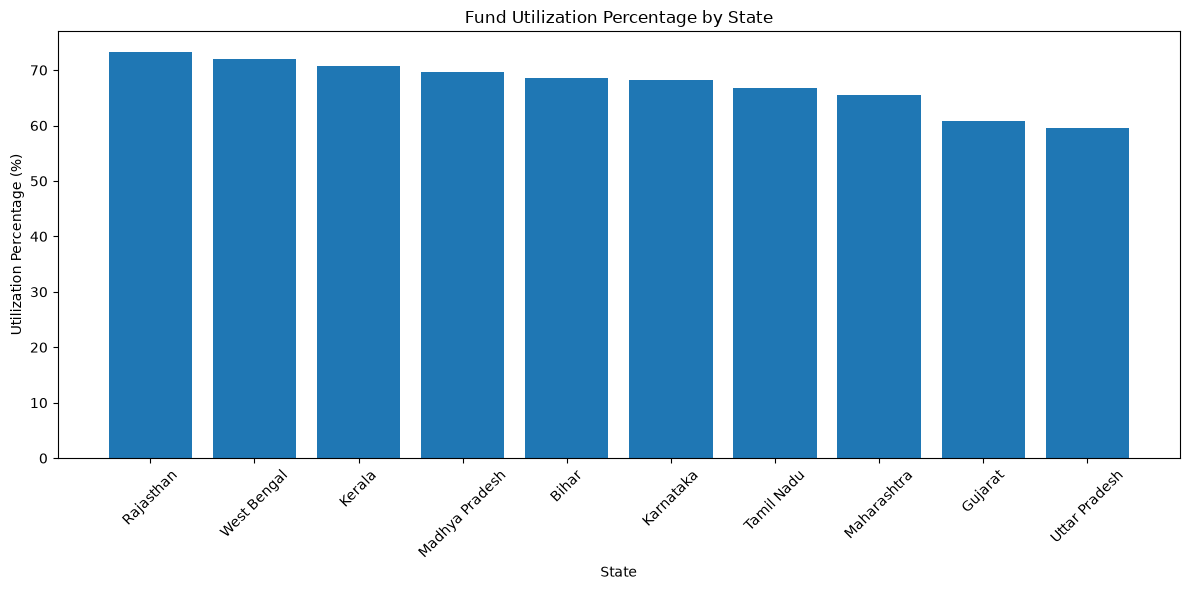

In [15]:
# Fund utilization by state

plt.figure(figsize=(12, 6))

plt.bar(
    state_analysis["State"],
    state_analysis["Calculated_Utilization_Percent"]
)

plt.title("Fund Utilization Percentage by State")
plt.xlabel("State")
plt.ylabel("Utilization Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

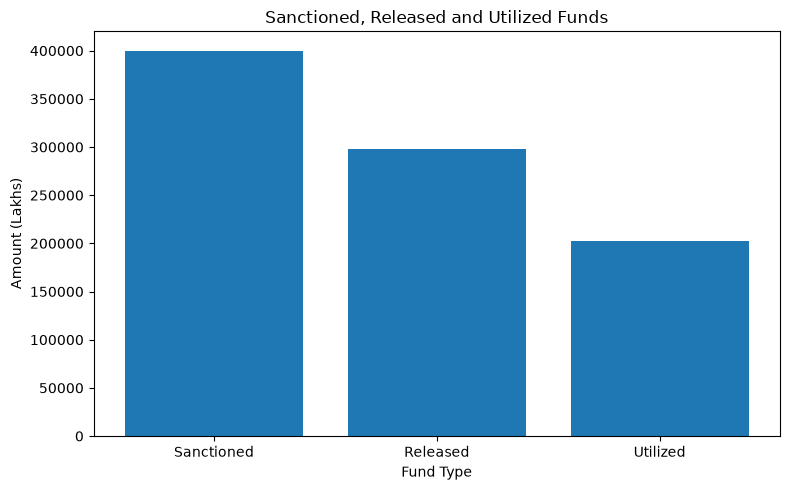

In [16]:
# Overall fund comparison

fund_comparison = pd.DataFrame({
    "Fund Type": [
        "Sanctioned",
        "Released",
        "Utilized"
    ],
    "Amount (Lakhs)": [
        total_sanctioned,
        total_released,
        total_utilized
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    fund_comparison["Fund Type"],
    fund_comparison["Amount (Lakhs)"]
)

plt.title("Sanctioned, Released and Utilized Funds")
plt.xlabel("Fund Type")
plt.ylabel("Amount (Lakhs)")

plt.tight_layout()
plt.show()

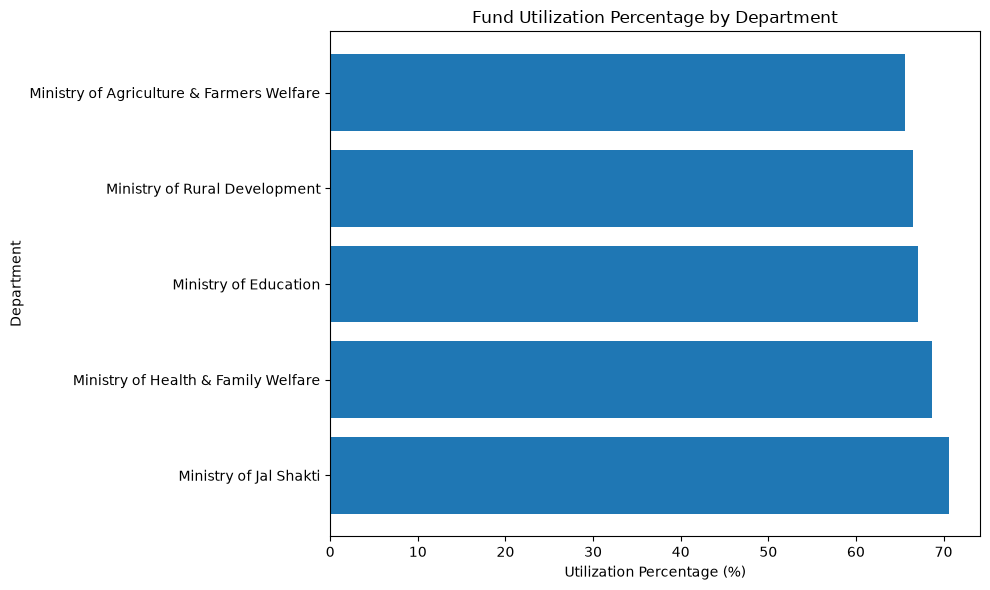

In [17]:
# Fund utilization by department

plt.figure(figsize=(10, 6))

plt.barh(
    department_analysis["Department"],
    department_analysis["Calculated_Utilization_Percent"]
)

plt.title("Fund Utilization Percentage by Department")
plt.xlabel("Utilization Percentage (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

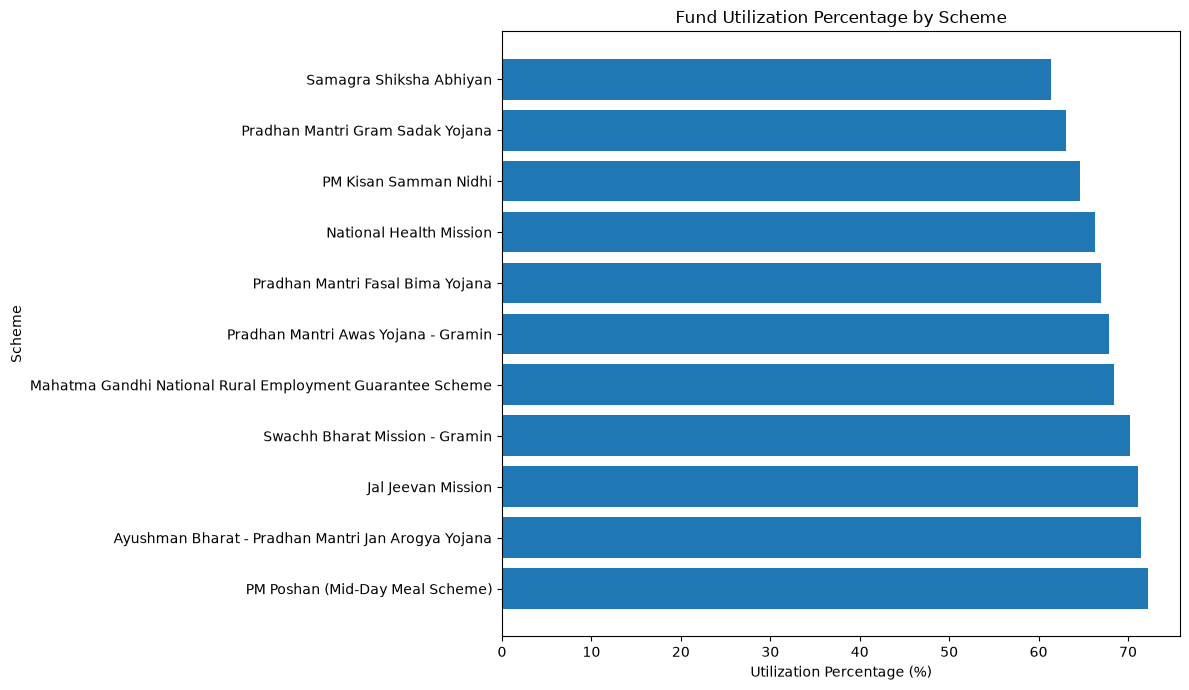

In [18]:
# Fund utilization by scheme

plt.figure(figsize=(12, 7))

plt.barh(
    scheme_analysis["Scheme_Name"],
    scheme_analysis["Calculated_Utilization_Percent"]
)

plt.title("Fund Utilization Percentage by Scheme")
plt.xlabel("Utilization Percentage (%)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.show()

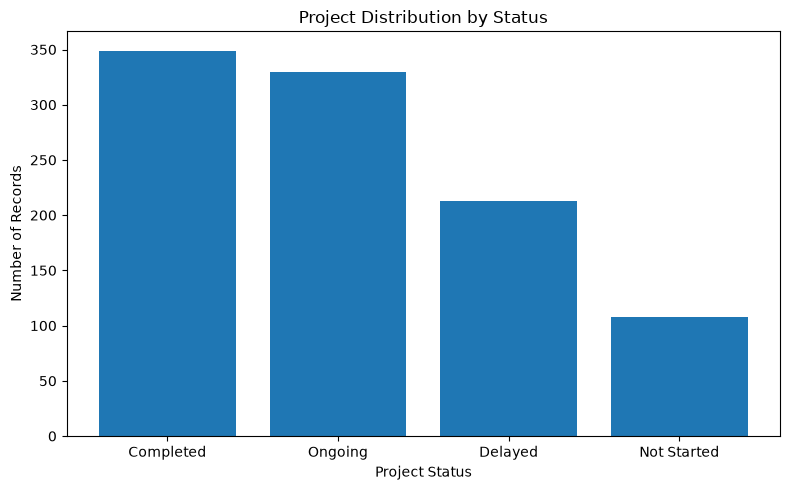

In [19]:
# Number of projects by status

status_counts = clean_df["Status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Project Distribution by Status")
plt.xlabel("Project Status")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

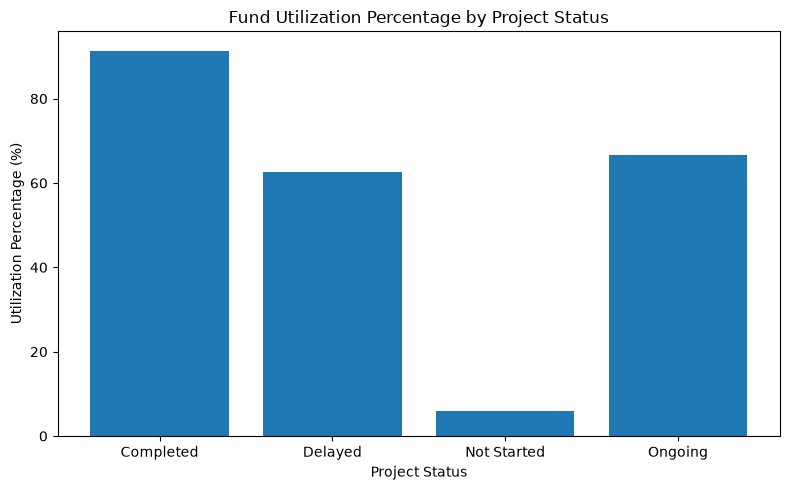

In [20]:
# Fund utilization by project status

plt.figure(figsize=(8, 5))

plt.bar(
    status_analysis["Status"],
    status_analysis["Calculated_Utilization_Percent"]
)

plt.title("Fund Utilization Percentage by Project Status")
plt.xlabel("Project Status")
plt.ylabel("Utilization Percentage (%)")

plt.tight_layout()
plt.show()

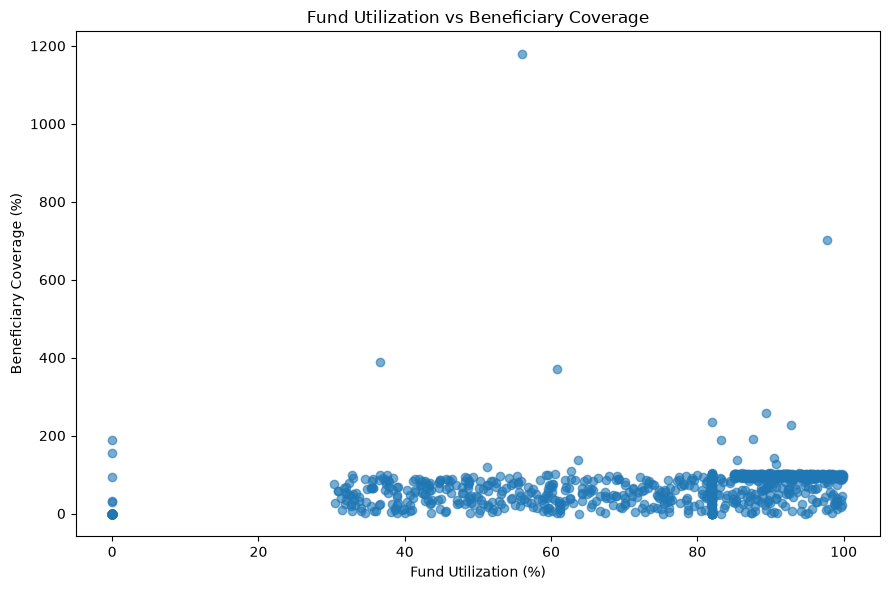

In [21]:
# Calculate beneficiary coverage percentage for each record

clean_df["Beneficiary_Coverage_Percent"] = (
    clean_df["Beneficiaries_Covered"]
    / clean_df["Beneficiaries_Target"]
) * 100

# Scatter plot

plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Utilization_Percent"],
    clean_df["Beneficiary_Coverage_Percent"],
    alpha=0.6
)

plt.title("Fund Utilization vs Beneficiary Coverage")
plt.xlabel("Fund Utilization (%)")
plt.ylabel("Beneficiary Coverage (%)")

plt.tight_layout()
plt.show()

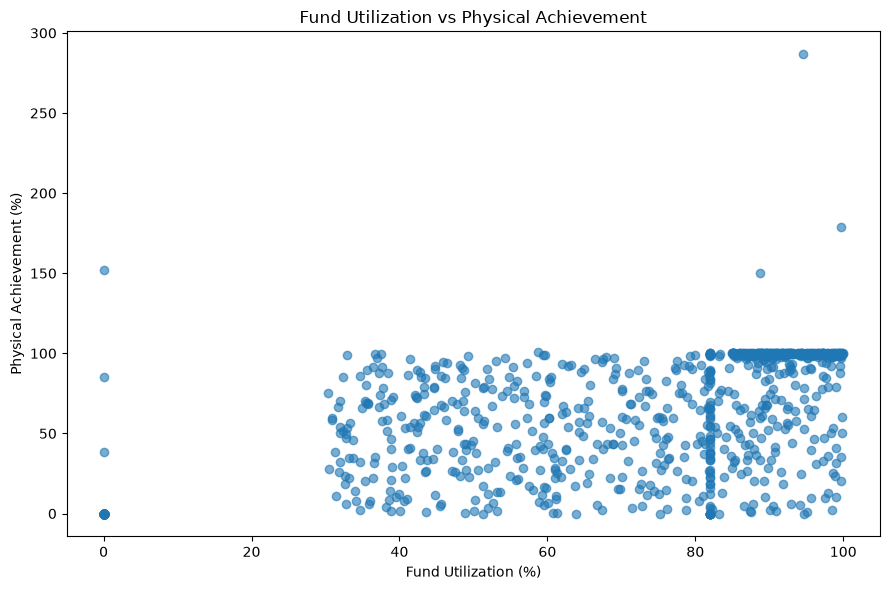

In [22]:
# Calculate physical achievement percentage

clean_df["Physical_Achievement_Percent"] = (
    clean_df["Physical_Achievement_Units"]
    / clean_df["Physical_Target_Units"]
) * 100

plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Utilization_Percent"],
    clean_df["Physical_Achievement_Percent"],
    alpha=0.6
)

plt.title("Fund Utilization vs Physical Achievement")
plt.xlabel("Fund Utilization (%)")
plt.ylabel("Physical Achievement (%)")

plt.tight_layout()
plt.show()

In [23]:
from scipy import stats

In [24]:
# Correlation analysis

correlation_columns = [
    "Utilization_Percent",
    "Physical_Achievement_Percent",
    "Beneficiary_Coverage_Percent"
]

correlation_matrix = clean_df[correlation_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Utilization_Percent,Physical_Achievement_Percent,Beneficiary_Coverage_Percent
Utilization_Percent,1.000000,0.628397,0.386506
Physical_Achievement_Percent,0.628397,1.000000,0.548186
Beneficiary_Coverage_Percent,0.386506,0.548186,1.000000


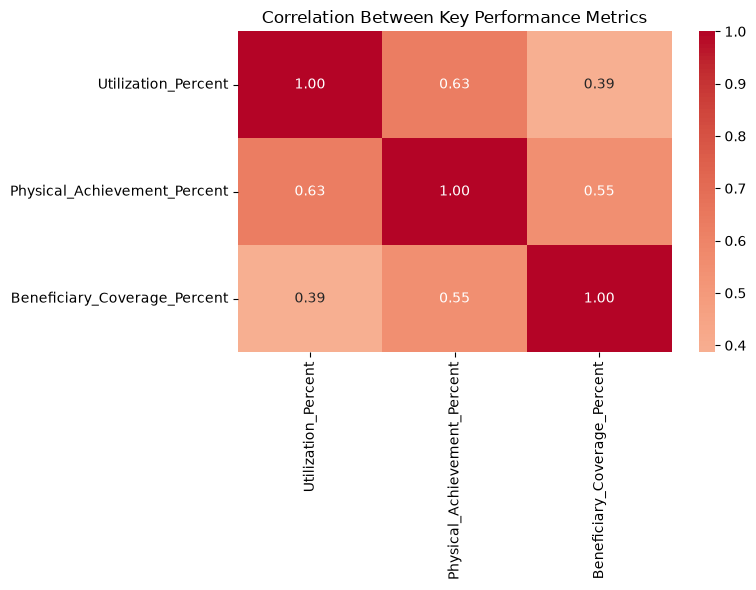

In [25]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Key Performance Metrics")
plt.tight_layout()

plt.show()

In [26]:
# Pearson correlation between fund utilization and physical achievement

r_physical, p_physical = stats.pearsonr(
    clean_df["Utilization_Percent"],
    clean_df["Physical_Achievement_Percent"]
)

print("Fund Utilization vs Physical Achievement")
print(f"Correlation coefficient (r): {r_physical:.4f}")
print(f"P-value: {p_physical:.4f}")

Fund Utilization vs Physical Achievement
Correlation coefficient (r): 0.6284
P-value: 0.0000


In [27]:
# Pearson correlation between fund utilization and beneficiary coverage

r_beneficiary, p_beneficiary = stats.pearsonr(
    clean_df["Utilization_Percent"],
    clean_df["Beneficiary_Coverage_Percent"]
)

print("Fund Utilization vs Beneficiary Coverage")
print(f"Correlation coefficient (r): {r_beneficiary:.4f}")
print(f"P-value: {p_beneficiary:.4f}")

Fund Utilization vs Beneficiary Coverage
Correlation coefficient (r): 0.3865
P-value: 0.0000


In [28]:
# Prepare utilization data by project status

completed = clean_df.loc[
    clean_df["Status"] == "Completed",
    "Utilization_Percent"
]

ongoing = clean_df.loc[
    clean_df["Status"] == "Ongoing",
    "Utilization_Percent"
]

delayed = clean_df.loc[
    clean_df["Status"] == "Delayed",
    "Utilization_Percent"
]

not_started = clean_df.loc[
    clean_df["Status"] == "Not Started",
    "Utilization_Percent"
]

print("Group sizes:")
print("Completed:", len(completed))
print("Ongoing:", len(ongoing))
print("Delayed:", len(delayed))
print("Not Started:", len(not_started))

Group sizes:
Completed: 349
Ongoing: 330
Delayed: 213
Not Started: 108


In [29]:
# One-way ANOVA

f_statistic, p_value = stats.f_oneway(
    completed,
    ongoing,
    delayed,
    not_started
)

print("One-Way ANOVA Results")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

One-Way ANOVA Results
F-statistic: 673.7816
P-value: 0.000000


## Statistical Interpretation

A one-way ANOVA was used to examine whether mean fund utilization percentage differs across the four project status groups: Completed, Ongoing, Delayed, and Not Started.

The p-value is used to assess whether the observed differences between group means are statistically significant at the 5% significance level.

- If p-value < 0.05, the analysis indicates a statistically significant difference in mean utilization across at least one of the status groups.
- If p-value >= 0.05, the analysis does not provide sufficient statistical evidence of a difference in mean utilization across the status groups.

Correlation analysis is used separately to examine the strength and direction of relationships between fund utilization, physical achievement, and beneficiary coverage.

# Key Findings

## Overall Fund Utilization

The dataset contains 1,000 government fund records covering 10 states, 11 schemes, and 5 departments. The total sanctioned amount is 400,073.92 lakhs, while 297,951.32 lakhs were released and 201,934.77 lakhs were utilized. The overall utilization of released funds is 67.77%.

## State-Level Findings

Fund utilization varies across the 10 states in the dataset. The calculated utilization percentage ranges from approximately 59.54% to 73.32%, indicating differences in the proportion of released funds utilized.

## Department-Level Findings

The calculated utilization percentage varies across the five departments. The department-level analysis provides a basis for comparing how released funds are being utilized across different administrative areas.

## Scheme-Level Findings

The 11 schemes show differences in both fund utilization and beneficiary coverage. This allows scheme-level analysis of financial utilization alongside beneficiary reach.

## Project Status Findings

The project-status analysis shows substantial differences in fund utilization across Completed, Ongoing, Delayed, and Not Started records. The one-way ANOVA produced an F-statistic of 673.7816 with a p-value below 0.001, indicating statistically significant differences in mean utilization across at least one of the status groups.

## Relationship Between Financial and Operational Outcomes

Fund utilization has a positive correlation with physical achievement (r = 0.6284, p < 0.001). Fund utilization also has a positive correlation with beneficiary coverage (r = 0.3865, p < 0.001).

These correlations indicate that higher utilization percentages are associated with higher physical achievement and beneficiary coverage in this dataset. Correlation does not by itself establish causation.

## Management Focus Areas

The analysis highlights the importance of monitoring fund utilization together with physical achievement, beneficiary coverage, and project status. State, department, scheme, and status-level breakdowns can be used to identify areas requiring further review.

In [30]:
# Final analysis verification

print("FINAL CAPSTONE ANALYSIS CHECK")
print("-" * 40)

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Cleaned columns:", len(clean_df.columns))
print("Duplicate rows:", clean_df.duplicated().sum())
print("Missing values:", clean_df.isnull().sum().sum())

print("\nOverall utilization:", f"{overall_utilization:.2f}%")
print("Physical achievement:", f"{physical_achievement_rate:.2f}%")
print("Beneficiary coverage:", f"{beneficiary_coverage_rate:.2f}%")

print("\nCorrelation - Physical Achievement:", f"{r_physical:.4f}")
print("Correlation - Beneficiary Coverage:", f"{r_beneficiary:.4f}")
print("ANOVA F-statistic:", f"{f_statistic:.4f}")
print("ANOVA p-value:", f"{p_value:.6f}")

print("\nAnalysis completed successfully.")

FINAL CAPSTONE ANALYSIS CHECK
----------------------------------------
Original rows: 1000
Cleaned rows: 1000
Cleaned columns: 22
Duplicate rows: 0
Missing values: 0

Overall utilization: 67.77%
Physical achievement: 64.18%
Beneficiary coverage: 61.41%

Correlation - Physical Achievement: 0.6284
Correlation - Beneficiary Coverage: 0.3865
ANOVA F-statistic: 673.7816
ANOVA p-value: 0.000000

Analysis completed successfully.


# Dashboard Dataset

A cleaned dashboard-ready dataset is created for Power BI visualization and reporting.

In [31]:
# Create dashboard-ready dataset

dashboard_columns = [
    "Financial_Year",
    "Date_of_Fund_Release",
    "State",
    "District",
    "Department",
    "Scheme_Name",
    "Fund_Source",
    "Implementing_Agency",
    "Sanctioned_Amount_Lakhs",
    "Fund_Released_Lakhs",
    "Fund_Utilized_Lakhs",
    "Utilization_Percent",
    "Physical_Target_Units",
    "Physical_Achievement_Units",
    "Physical_Achievement_Percent",
    "Beneficiaries_Target",
    "Beneficiaries_Covered",
    "Beneficiary_Coverage_Percent",
    "Status"
]

dashboard_df = clean_df[dashboard_columns].copy()

dashboard_df.to_csv("capstone_dashboard_data.csv", index=False)

print("Dashboard dataset created successfully.")
print("Rows:", len(dashboard_df))
print("Columns:", len(dashboard_df.columns))
print("File: capstone_dashboard_data.csv")

Dashboard dataset created successfully.
Rows: 1000
Columns: 19
File: capstone_dashboard_data.csv


In [32]:
print(dashboard_df.head())
print("\nMissing values:", dashboard_df.isnull().sum().sum())
print("Duplicate rows:", dashboard_df.duplicated().sum())

  Financial_Year Date_of_Fund_Release        State            District  \
0        2022-23           2021-08-25  West Bengal           Siliguri    
1        2021-22           2023-04-16   Tamil Nadu               Salem   
2        2023-24           2023-01-31       Kerala  Thiruvananthapuram   
3        2023-24           2024-08-29  West Bengal             Asansol   
4        2021-22           2021-06-21    Karnataka            Belagavi   

                                  Department  \
0  Ministry of Agriculture & Farmers Welfare   
1  Ministry of Agriculture & Farmers Welfare   
2        Ministry of Health & Family Welfare   
3                      Ministry of Education   
4              Ministry of Rural Development   

                           Scheme_Name                  Fund_Source  \
0                PM Kisan Samman Nidhi               Central Sector   
1     Pradhan Mantri Fasal Bima Yojana               Central Sector   
2              National Health Mission  Centrally Spo